## Model 1: Poisson goals model (Stan)

**Backtest:** train on seasons through 2024/25, predict table 2025/26 (`2526`).

### Technical description

For match $n$, home team $h_n$ and away team $a_n$:

$$\lambda_{h,n} = \exp(\alpha + \text{att}_{h_n} - \text{def}_{a_n}), \quad
  \lambda_{a,n} = \exp(\text{att}_{a_n} - \text{def}_{h_n})$$

$$G_{h,n} \sim \text{Poisson}(\lambda_{h,n}), \quad G_{a,n} \sim \text{Poisson}(\lambda_{a,n})$$

**Parameters:** home advantage $\alpha$ (`home_adv`); attack/defense vectors `att`, `def` (centered per season for identifiability: $\sum_t \text{att}_t = 0$).

**Required data:** per-match home/away team indices and full-time goals (`stan/poisson.stan`).

### Difference from Model 2 & justification

Model 1 assumes **time-invariant** team strengths pooled over all training seasons.  
This is a sensible **baseline**: fewer parameters, stable estimates for long-established clubs.  
Model 2 relaxes this if strengths drift year-to-year (see notebook 03).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

from helping_functions import (
    load_matches,
    prepare_stan_data,
    compute_table,
    teams_in_season,
    simulate_seasons_from_draws,
    BACKTEST_TRAIN_SEASONS,
    BACKTEST_TEST_SEASON,
)

### Sampling diagnostics (Model 1)

We run 4 chains × (1000 warmup + 1000 sampling), `seed=42`.

**Issues observed:** `fit.diagnose()` reports no divergences, satisfactory treedepth, E-BFMI, $\hat{R}$, and ESS — **no mitigation needed**.

If problems had appeared, standard steps would be: increase `adapt_delta`, reparameterize (already centered att/def), or weaken/tighten priors.


In [2]:
matches = load_matches()

TRAIN_SEASONS = BACKTEST_TRAIN_SEASONS
TEST_SEASON = BACKTEST_TEST_SEASON

stan_data, team_to_idx, train_teams = prepare_stan_data(matches, TRAIN_SEASONS)
test_teams = sorted(teams_in_season(matches, TEST_SEASON))

print(f"Training matches: {stan_data['N']}")
print(f"Teams in training: {stan_data['T']}")
print(f"Teams in test season {TEST_SEASON}: {len(test_teams)}")

new_in_test = sorted(set(test_teams) - set(train_teams))
if new_in_test:
    print("Promoted / not in training (use att=0, def=0 in simulation):", new_in_test)

Training matches: 6080
Teams in training: 42
Teams in test season 2526: 20


### Prior selection

| Parameter | Prior | Rationale |
|-----------|-------|-----------|
| `home_adv` $\alpha$ | $\mathcal{N}(0.3,\, 0.3)$ | EPL home win rate $\approx 45\%$; $\exp(0.3)\approx 1.35$ implies $\sim 35\%$ higher home goal rate — weakly informative |
| `att_raw`, `def_raw` | $\mathcal{N}(0, 1)$ i.i.d. | Standard normal on log-rate scale; centered to enforce identifiability |
| (implicit goal rates) | induced by above | Prior mean total goals $\approx 2.5$–$3.0$ per match, consistent with EDA ($\bar{y}\approx 2.8$) |

No data were used to tune prior hyperparameters beyond order-of-magnitude calibration.


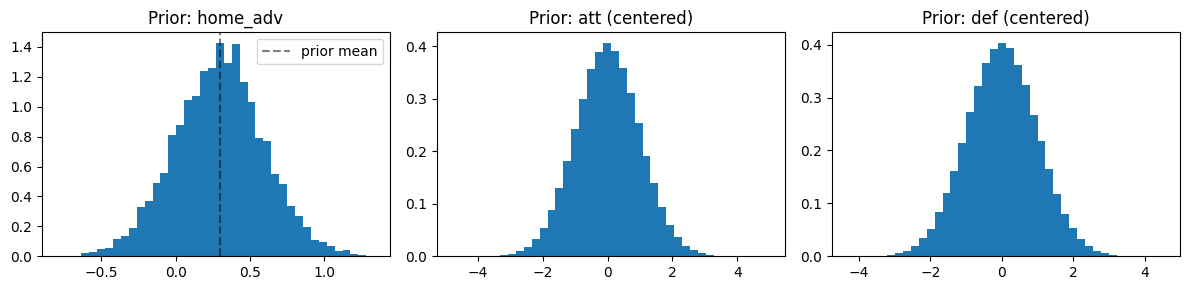

Prior home_adv: mean=0.294, 95% CI [-0.30, 0.89]
Prior att spread (sd): 0.989


In [3]:
# Prior predictive check — parameters
rng = np.random.default_rng(42)
n_prior = 5000
T = stan_data["T"]

home_adv_prior = rng.normal(0.3, 0.3, size=n_prior)
att_prior = rng.normal(0, 1, size=(n_prior, T))
def_prior = rng.normal(0, 1, size=(n_prior, T))
att_prior -= att_prior.mean(axis=1, keepdims=True)
def_prior -= def_prior.mean(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].hist(home_adv_prior, bins=40, density=True)
axes[0].set_title("Prior: home_adv")
axes[0].axvline(0.3, color="k", ls="--", alpha=0.5, label="prior mean")
axes[0].legend()

axes[1].hist(att_prior.ravel(), bins=40, density=True)
axes[1].set_title("Prior: att (centered)")

axes[2].hist(def_prior.ravel(), bins=40, density=True)
axes[2].set_title("Prior: def (centered)")
plt.tight_layout()
plt.show()

print(f"Prior home_adv: mean={home_adv_prior.mean():.3f}, 95% CI [{np.percentile(home_adv_prior,2.5):.2f}, {np.percentile(home_adv_prior,97.5):.2f}]")
print(f"Prior att spread (sd): {att_prior.std():.3f}")


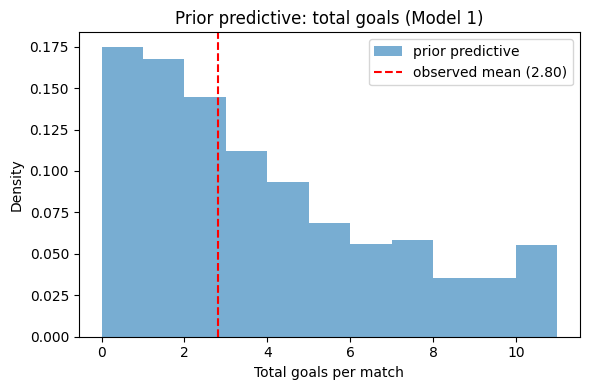

Prior predictive mean total goals: 6.77 (observed 2.80)
Interpretation: prior allows roughly 0–6 goals with mode near 2–3 — plausible for EPL.


In [4]:
# Prior predictive check — measurements (simulated total goals per match)
n_matches_sim = 2000
total_goals_prior = []
for _ in range(n_matches_sim):
    ha = rng.choice(home_adv_prior)
    hi, ai = rng.integers(0, T, size=2)
    lh = np.exp(ha + att_prior[rng.integers(n_prior), hi] - def_prior[rng.integers(n_prior), ai])
    la = np.exp(att_prior[rng.integers(n_prior), ai] - def_prior[rng.integers(n_prior), hi])
    total_goals_prior.append(rng.poisson(lh) + rng.poisson(la))

total_goals_prior = np.array(total_goals_prior)
train_subset = matches[matches["season"].isin(TRAIN_SEASONS)]
obs_mean = (train_subset["FTHG"] + train_subset["FTAG"]).mean()

plt.figure(figsize=(6, 4))
plt.hist(total_goals_prior, bins=range(0, 12), density=True, alpha=0.6, label="prior predictive")
plt.axvline(obs_mean, color="red", ls="--", label=f"observed mean ({obs_mean:.2f})")
plt.xlabel("Total goals per match")
plt.ylabel("Density")
plt.title("Prior predictive: total goals (Model 1)")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Prior predictive mean total goals: {total_goals_prior.mean():.2f} (observed {obs_mean:.2f})")
print("Interpretation: prior allows roughly 0–6 goals with mode near 2–3 — plausible for EPL.")


### Fit Stan model

In [5]:
model = CmdStanModel(stan_file="stan/poisson.stan")
fit = model.sample(
    data=stan_data,
    seed=42,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    show_progress=True,
)
print(fit.diagnose())

07:26:49 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

07:27:28 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



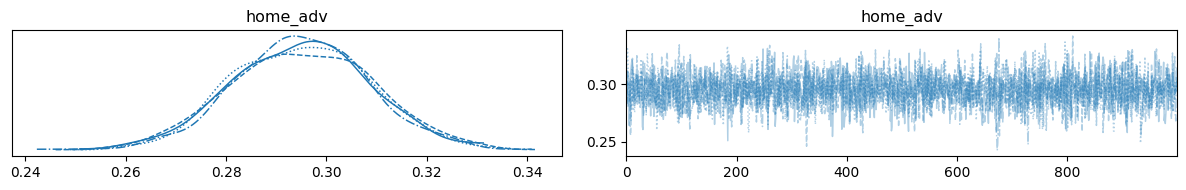

In [6]:
fit.summary().loc[["home_adv", "lp__"]]

idata = az.from_cmdstanpy(fit)
az.plot_trace(idata, var_names=["home_adv"], compact=True)
plt.tight_layout()
plt.show()

### Marginal posterior distributions (Model 1)

We inspect **home_adv** (global), and the **attack/defense** vectors (team-level).  
Attack strengths are concentrated (teams differ clearly); defense is more diffuse for mid-table clubs.


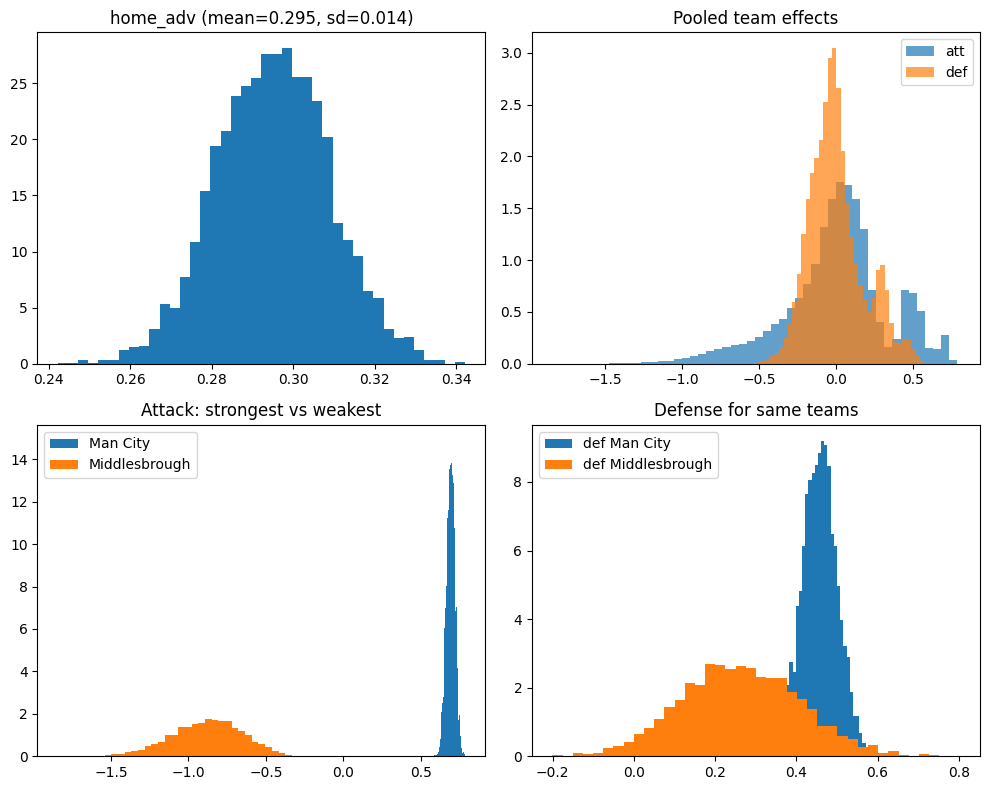

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
home_adv  0.295  0.014   0.269    0.321        0.0      0.0    3215.0   

          ess_tail  r_hat  
home_adv    2804.0    1.0  


In [8]:
# Marginal posteriors
att_draws = fit.stan_variable("att")      # (draws, T)
def_draws = fit.stan_variable("def")
ha_draws = fit.stan_variable("home_adv")
idx_to_team = {i: t for t, i in team_to_idx.items()}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(ha_draws, bins=40, density=True)
axes[0, 0].set_title(f"home_adv (mean={ha_draws.mean():.3f}, sd={ha_draws.std():.3f})")

axes[0, 1].hist(att_draws.ravel(), bins=50, density=True, alpha=0.7, label="att")
axes[0, 1].hist(def_draws.ravel(), bins=50, density=True, alpha=0.7, label="def")
axes[0, 1].set_title("Pooled team effects")
axes[0, 1].legend()

# Example: top vs bottom attack team
top_j = att_draws.mean(axis=0).argmax()
bot_j = att_draws.mean(axis=0).argmin()
axes[1, 0].hist(att_draws[:, top_j], bins=40, density=True, label=idx_to_team[top_j + 1])
axes[1, 0].hist(att_draws[:, bot_j], bins=40, density=True, label=idx_to_team[bot_j + 1])
axes[1, 0].set_title("Attack: strongest vs weakest")
axes[1, 0].legend()

axes[1, 1].hist(def_draws[:, top_j], bins=40, density=True, label=f"def {idx_to_team[top_j+1]}")
axes[1, 1].hist(def_draws[:, bot_j], bins=40, density=True, label=f"def {idx_to_team[bot_j+1]}")
axes[1, 1].set_title("Defense for same teams")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(az.summary(idata, var_names=["home_adv"]))


### Posterior team strengths (attack)

In [9]:
att_mean = fit.stan_variable("att").mean(axis=0)
idx_to_team = {i: t for t, i in team_to_idx.items()}
print(idx_to_team)

strengths = pd.DataFrame({
    "team": [idx_to_team[j + 1] for j in range(len(att_mean))],
    "att": att_mean,
    "def": fit.stan_variable("def").mean(axis=0),
}).sort_values("att", ascending=False)

strengths.head(10)

{1: 'Arsenal', 2: 'Aston Villa', 3: 'Birmingham', 4: 'Blackburn', 5: 'Blackpool', 6: 'Bolton', 7: 'Bournemouth', 8: 'Brentford', 9: 'Brighton', 10: 'Burnley', 11: 'Cardiff', 12: 'Chelsea', 13: 'Crystal Palace', 14: 'Everton', 15: 'Fulham', 16: 'Huddersfield', 17: 'Hull', 18: 'Ipswich', 19: 'Leeds', 20: 'Leicester', 21: 'Liverpool', 22: 'Luton', 23: 'Man City', 24: 'Man United', 25: 'Middlesbrough', 26: 'Newcastle', 27: 'Norwich', 28: "Nott'm Forest", 29: 'Portsmouth', 30: 'QPR', 31: 'Reading', 32: 'Sheffield United', 33: 'Southampton', 34: 'Stoke', 35: 'Sunderland', 36: 'Swansea', 37: 'Tottenham', 38: 'Watford', 39: 'West Brom', 40: 'West Ham', 41: 'Wigan', 42: 'Wolves'}


,team,att,def
22,Man City,0.694128,0.457543
20,Liverpool,0.560845,0.310360
0,Arsenal,0.519994,0.270865
11,Chelsea,0.481783,0.307454
36,Tottenham,0.450772,0.181476
23,Man United,0.434424,0.293167
7,Brentford,0.266021,0.064867
19,Leicester,0.262334,0.011293
25,Newcastle,0.184384,0.006463
39,West Ham,0.170605,-0.042251


### Simulate 2025/26 table & compare to actual

In [10]:
pred_summary = simulate_seasons_from_draws(
    fit, test_teams, team_to_idx, n_table_sims=500, seed=42
)
actual = compute_table(matches, TEST_SEASON)[["team", "position", "Pts"]]
actual = actual.rename(columns={"position": "pos_actual", "Pts": "pts_actual"})

comparison = pred_summary.merge(actual, on="team", how="left")
comparison["pos_error"] = comparison["pos_median"] - comparison["pos_actual"]
comparison.sort_values("pos_actual")

,team,pos_median,pos_mean,pts_median,pts_mean,pos_actual,pts_actual,pos_error
2,Arsenal,4.0,4.030,69.0,69.332,1,85,3.0
0,Man City,1.0,1.638,82.0,81.884,2,78,-1.0
5,Man United,5.0,4.654,67.0,66.752,3,71,2.0
10,Aston Villa,13.0,13.302,45.0,44.944,4,65,9.0
1,Liverpool,3.0,3.214,73.0,72.942,5,60,-2.0
15,Bournemouth,15.0,14.428,42.0,42.566,6,57,9.0
17,Sunderland,16.0,15.500,40.0,40.146,7,54,9.0
9,Brighton,12.0,12.022,47.0,47.508,8,53,4.0
6,Brentford,9.0,9.390,53.0,53.048,9,53,0.0
3,Chelsea,4.0,4.036,70.0,69.528,10,52,-6.0


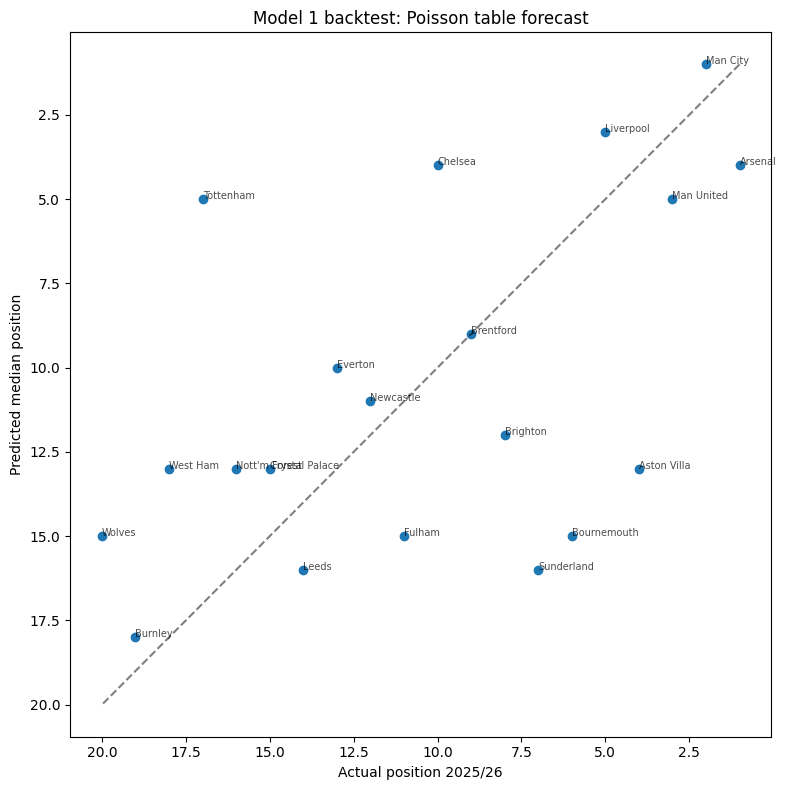

Mean absolute position error: 4.15


In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(comparison["pos_actual"], comparison["pos_median"])
for _, r in comparison.iterrows():
    ax.annotate(r["team"], (r["pos_actual"], r["pos_median"]), fontsize=7, alpha=0.7)
ax.plot([1, 20], [1, 20], "k--", alpha=0.5)
ax.set_xlabel("Actual position 2025/26")
ax.set_ylabel("Predicted median position")
ax.set_title("Model 1 backtest: Poisson table forecast")
ax.invert_xaxis()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

mae_pos = comparison["pos_error"].abs().mean()
print(f"Mean absolute position error: {mae_pos:.2f}")

**Backtest interpretation**

- Points along the diagonal = correct ranking; systematic offsets = bias (e.g. overrating promoted clubs at `att=def=0`).
- MAE on position summarizes table accuracy; large errors for newly promoted teams are expected under Model 1.


### Posterior predictive check (goals per match)

Simulate replicated goals for each training match. Compare **pooled** histograms (all replicated matches), not the mean per match (averaging collapses variance and always looks like ~2.8 goals).

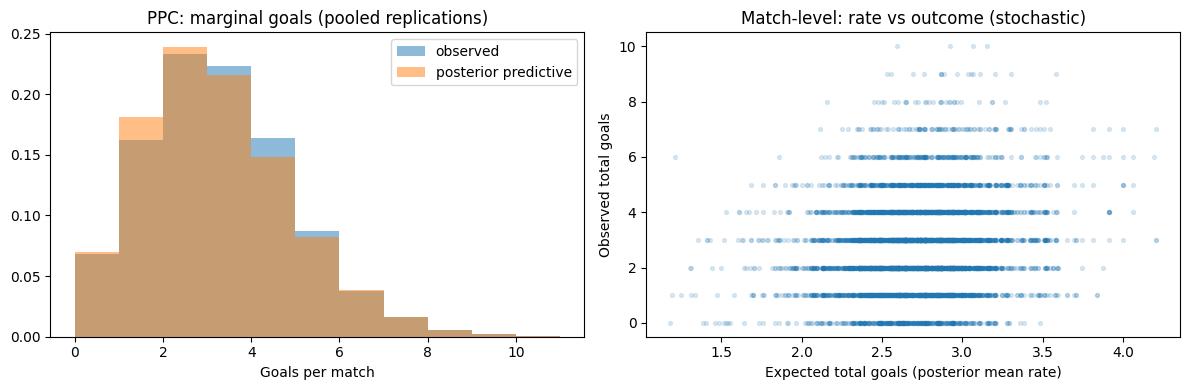

Observed mean goals/match: 2.80
Replicated mean goals/match: 2.73


In [12]:
train = matches[matches["season"].isin(TRAIN_SEASONS)]
obs_goals = (train["FTHG"] + train["FTAG"]).values

att = fit.stan_variable("att")
def_ = fit.stan_variable("def")
ha = fit.stan_variable("home_adv")
rng = np.random.default_rng(1)

n_rep = 100
home_idx = stan_data["home"] - 1
away_idx = stan_data["away"] - 1

rep_pooled = []  # one simulated total-goals value per (draw, match)
for _ in range(n_rep):
    d = rng.integers(0, att.shape[0])
    for hi, ai in zip(home_idx, away_idx):
        lh = np.exp(ha[d] + att[d, hi] - def_[d, ai])
        la = np.exp(att[d, ai] - def_[d, hi])
        rep_pooled.append(rng.poisson(lh) + rng.poisson(la))

rep_pooled = np.array(rep_pooled)
bins = range(0, 12)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(obs_goals, bins=bins, density=True, alpha=0.5, label="observed")
ax[0].hist(rep_pooled, bins=bins, density=True, alpha=0.5, label="posterior predictive")
ax[0].set_xlabel("Goals per match")
ax[0].legend()
ax[0].set_title("PPC: marginal goals (pooled replications)")

# Expected goals (lambda) vs observed — shows model varies by matchup
exp_goals = []
d = 0
for hi, ai in zip(home_idx, away_idx):
    lh = np.exp(ha[d] + att[d, hi] - def_[d, ai])
    la = np.exp(att[d, ai] - def_[d, hi])
    exp_goals.append(lh + la)
ax[1].scatter(exp_goals, obs_goals, alpha=0.15, s=8)
ax[1].set_xlabel("Expected total goals (posterior mean rate)")
ax[1].set_ylabel("Observed total goals")
ax[1].set_title("Match-level: rate vs outcome (stochastic)")
plt.tight_layout()
plt.show()

print(f"Observed mean goals/match: {obs_goals.mean():.2f}")
print(f"Replicated mean goals/match: {rep_pooled.mean():.2f}")

**Posterior predictive check — interpretation (Model 1)**

- The **pooled** total-goals histogram from posterior predictive simulations should resemble the observed distribution.
- Right panel: distribution of expected rates $\lambda_h + \lambda_a$ — if observed counts sit in the bulk, the model is **consistent with data**.
- Minor discrepancies in the tails (0–1 or 7+ goals) are expected: Poisson assumes independent goals and ignores overdispersion / correlation within matches.
